In [1]:
import zipfile
import os
import random
import matplotlib.pyplot as plt
from PIL import Image
import tensorflow as tf
import keras
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping
from sklearn.metrics import classification_report
import warnings
warnings.filterwarnings('ignore')


In [2]:
print(f"TensorFlow version : {tf.__version__}")
print(f"Keras version      : {keras.__version__}")


TensorFlow version : 2.19.0
Keras version      : 3.13.2


In [3]:
zip_file_path = '/content/FruitinAmazon.zip'
extract_dir = '/content/extracted_dataset'

# Create the extraction directory if it doesn't exist
os.makedirs(extract_dir, exist_ok=True)

with zipfile.ZipFile(zip_file_path, 'r') as zip_ref:
    zip_ref.extractall(extract_dir)

print(f"'{zip_file_path}' extracted to '{extract_dir}'")

# List contents of the extracted directory to verify
print(f"Contents of '{extract_dir}':\n{os.listdir(extract_dir)}")

'/content/FruitinAmazon.zip' extracted to '/content/extracted_dataset'
Contents of '/content/extracted_dataset':
['FruitinAmazon', '__MACOSX']


Found 6 classes: ['acai', 'cupuacu', 'graviola', 'guarana', 'pupunha', 'tucuma']


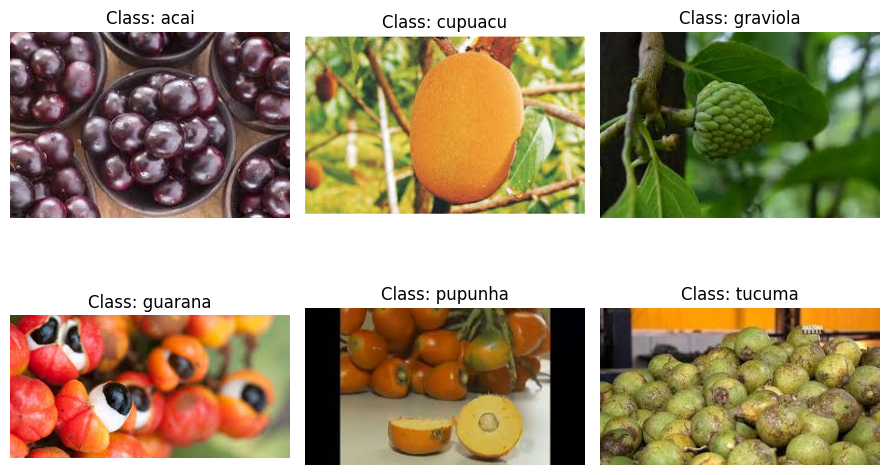

In [4]:
train_dir = '/content/extracted_dataset/FruitinAmazon/train'
# Get the list of class directories from the train folder
class_dirs = [d for d in os.listdir(train_dir) if os.path.isdir(os.path.join(train_dir, d))]
class_dirs.sort() # Sort for consistent order

if not class_dirs:
    print(f"No class directories found in {train_dir}. Please check your dataset structure.")
else:
    print(f"Found {len(class_dirs)} classes: {class_dirs}")

    # Select one random image from each class
    selected_images = {}
    for class_name in class_dirs:
        class_path = os.path.join(train_dir, class_name)
        images_in_class = [f for f in os.listdir(class_path) if os.path.isfile(os.path.join(class_path, f)) and f.lower().endswith(('.png', '.jpg', '.jpeg', '.gif', '.bmp'))]
        if images_in_class:
            selected_images[class_name] = os.path.join(class_path, random.choice(images_in_class))
        else:
            print(f"Warning: No images found in class '{class_name}'. Skipping.")

    if not selected_images:
        print("No images were selected to display.")
    else:
        # Display the images in a grid format with two rows using matplotlib
        num_images = len(selected_images)
        num_cols = (num_images + 1) // 2  # Calculate columns for a 2-row grid
        num_rows = 2

        plt.figure(figsize=(num_cols * 3, num_rows * 3))
        for i, (class_name, image_path) in enumerate(selected_images.items()):
            plt.subplot(num_rows, num_cols, i + 1)
            try:
                img = Image.open(image_path)
                plt.imshow(img)
                plt.title(f"Class: {class_name}")
                plt.axis('off')
            except Exception as e:
                print(f"Error loading image {image_path}: {e}")
                plt.title(f"Error: {class_name}")
                plt.axis('off')

        plt.tight_layout()
        plt.show()

In [5]:
corrupted_images_removed = []

# Iterate through each class subdirectory in the train directory
for class_name in os.listdir(train_dir):
    class_path = os.path.join(train_dir, class_name)

    # Ensure it's a directory before proceeding
    if os.path.isdir(class_path):
        for image_filename in os.listdir(class_path):
            image_path = os.path.join(class_path, image_filename)

            # Check if it's a file and a potential image
            if os.path.isfile(image_path) and image_filename.lower().endswith(('.png', '.jpg', '.jpeg', '.gif', '.bmp')):
                try:
                    with Image.open(image_path) as img:
                        img.verify() # Verify that it is an image
                except (IOError, SyntaxError) as e:
                    # Image is corrupted, remove it
                    os.remove(image_path)
                    corrupted_images_removed.append(image_path)
                    print(f"Removed corrupted image: {image_path} (Error: {e})")

if not corrupted_images_removed:
    print("No Corrupted Images Found.")
else:
    print(f"\nSummary: Removed {len(corrupted_images_removed)} corrupted images.")

No Corrupted Images Found.


In [6]:
# Define image size and batch size
img_height = 128  # Example image height
img_width = 128   # Example image width
batch_size = 32
validation_split = 0.2  # 80% training, 20% validation

# Create a preprocessing layer for normalization
rescale = tf.keras.layers.Rescaling(1. / 255)  # Normalize pixel values to [0, 1]

# Create training dataset with normalization
train_ds = tf.keras.preprocessing.image_dataset_from_directory(
    train_dir,
    labels='inferred',
    label_mode='int',
    image_size=(img_height, img_width),
    interpolation='nearest',
    batch_size=batch_size,
    shuffle=True,
    validation_split=validation_split,
    subset='training',
    seed=123
)

# Apply normalization
train_ds = train_ds.map(lambda x, y: (rescale(x), y))

# Create validation dataset with normalization
val_ds = tf.keras.preprocessing.image_dataset_from_directory(
    train_dir,
    labels='inferred',
    label_mode='int',
    image_size=(img_height, img_width),
    interpolation='nearest',
    batch_size=batch_size,
    shuffle=False,
    validation_split=validation_split,
    subset='validation',
    seed=123
)

# Apply normalization
val_ds = val_ds.map(lambda x, y: (rescale(x), y))

Found 90 files belonging to 6 classes.
Using 72 files for training.
Found 90 files belonging to 6 classes.
Using 18 files for validation.


In [7]:
def build_cnn(num_classes, img_height=128, img_width=128):
    """
    Builds a CNN with the architecture specified in Worksheet 5 Task 3.

    Convolutional section:
        Conv2D(32, 3x3, same, ReLU) → MaxPool(2x2)
        Conv2D(32, 3x3, same, ReLU) → MaxPool(2x2)

    Fully Connected section:
        Flatten → Dense(128, ReLU) → Dense(64, ReLU) → Dense(num_classes, softmax)
    """
    model = keras.Sequential([
        #  Input
        layers.InputLayer(input_shape=(img_height, img_width, 3)),

        # Convolutional Block 1
        layers.Conv2D(
            filters     = 32,
            kernel_size = (3, 3),
            strides     = (1, 1),
            padding     = 'same',
            activation  = 'relu',
            name        = 'conv1'
        ),
        layers.MaxPooling2D(pool_size=(2, 2), strides=2, name='pool1'),

        #  Convolutional Block 2
        layers.Conv2D(
            filters     = 32,
            kernel_size = (3, 3),
            strides     = (1, 1),
            padding     = 'same',
            activation  = 'relu',
            name        = 'conv2'
        ),
        layers.MaxPooling2D(pool_size=(2, 2), strides=2, name='pool2'),

        #  Fully Connected Network
        layers.Flatten(name='flatten'),

        layers.Dense(128, activation='relu', name='dense_128'),
        layers.Dense(64,  activation='relu', name='dense_64'),

        # Output Layer
        layers.Dense(num_classes, activation='softmax', name='output')
    ], name="CNN_FruitClassifier")

    return model

# Define NUM_CLASSES using the length of class_dirs, which was previously determined
NUM_CLASSES = len(class_dirs)

model = build_cnn(NUM_CLASSES)
model.summary()

Model: "CNN_FruitClassifier"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1 (Conv2D)                  │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool1 (MaxPooling2D)            │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2 (Conv2D)                  │ (None, 64, 64, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool2 (MaxPooling2D)            │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 32768)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_128 (Dense)               │ (None, 128)            │     4,194,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_64 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 6)              │           390 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,213,222 (16.07 MB)

 Trainable params: 4,213,222 (16.07 MB)

 Non-trainable params: 0 (0.00 B)

In [8]:
model.compile(
    optimizer = 'adam',
    loss      = 'sparse_categorical_crossentropy',
    metrics   = ['accuracy']
)

In [9]:
#  Callbacks

# Saves the best model (by val_accuracy) during training
checkpoint_cb = ModelCheckpoint(
    filepath        = 'best_model.h5',
    monitor         = 'val_accuracy',
    save_best_only  = True,
    save_weights_only = False,
    verbose         = 1
)

# Stops training if val_loss doesn't improve for `patience` epochs
early_stop_cb = EarlyStopping(
    monitor              = 'val_loss',
    patience             = 20,          # allow some variance before stopping
    restore_best_weights = True,
    verbose              = 1
)

callbacks = [checkpoint_cb, early_stop_cb]

In [10]:
# Train
EPOCHS = 250

history = model.fit(
    train_ds,
    epochs          = EPOCHS,
    validation_data = val_ds,
    callbacks       = callbacks,
    verbose         = 1
)

print(f"\n Training complete. Ran {len(history.history['accuracy'])} epochs.")

Epoch 1/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 352ms/step - accuracy: 0.1858 - loss: 2.1700
Epoch 1: val_accuracy improved from None to 0.83333, saving model to best_model.h5



Epoch 1: finished saving model to best_model.h5
3/3 ━━━━━━━━━━━━━━━━━━━━ 4s 596ms/step - accuracy: 0.1667 - loss: 2.4032 - val_accuracy: 0.8333 - val_loss: 0.6964
Epoch 2/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 339ms/step - accuracy: 0.1331 - loss: 2.5215
Epoch 2: val_accuracy did not improve from 0.83333
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 411ms/step - accuracy: 0.1806 - loss: 2.4229 - val_accuracy: 0.0000e+00 - val_loss: 1.4616
Epoch 3/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 341ms/step - accuracy: 0.1690 - loss: 1.8808
Epoch 3: val_accuracy did not improve from 0.83333
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 411ms/step - accuracy: 0.1944 - loss: 1.8365 - val_accuracy: 0.0000e+00 - val_loss: 1.8173
Epoch 4/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 360ms/step - accuracy: 0.3148 - loss: 1.7116
Epoch 4: val_accuracy did not improve from 0.83333
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 447ms/step - accuracy: 0.3194 - loss: 1.7055 - val_accuracy: 0.1667 - val_loss: 1.7399
Epoch 5/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 349ms/step - accuracy: 0.5203 - los


Epoch 12: finished saving model to best_model.h5
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 482ms/step - accuracy: 0.9722 - loss: 0.1680 - val_accuracy: 0.9444 - val_loss: 0.2097
Epoch 13/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 604ms/step - accuracy: 0.9705 - loss: 0.1182
Epoch 13: val_accuracy did not improve from 0.94444
3/3 ━━━━━━━━━━━━━━━━━━━━ 3s 731ms/step - accuracy: 0.9583 - loss: 0.1426 - val_accuracy: 0.8889 - val_loss: 0.3237
Epoch 14/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 487ms/step - accuracy: 1.0000 - loss: 0.0432
Epoch 14: val_accuracy did not improve from 0.94444
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 597ms/step - accuracy: 1.0000 - loss: 0.0421 - val_accuracy: 0.7778 - val_loss: 0.7615
Epoch 15/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 345ms/step - accuracy: 0.9809 - loss: 0.0557
Epoch 15: val_accuracy did not improve from 0.94444
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 415ms/step - accuracy: 0.9583 - loss: 0.0764 - val_accuracy: 0.8333 - val_loss: 0.4998
Epoch 16/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 343ms/step - accuracy: 0.9797 - los

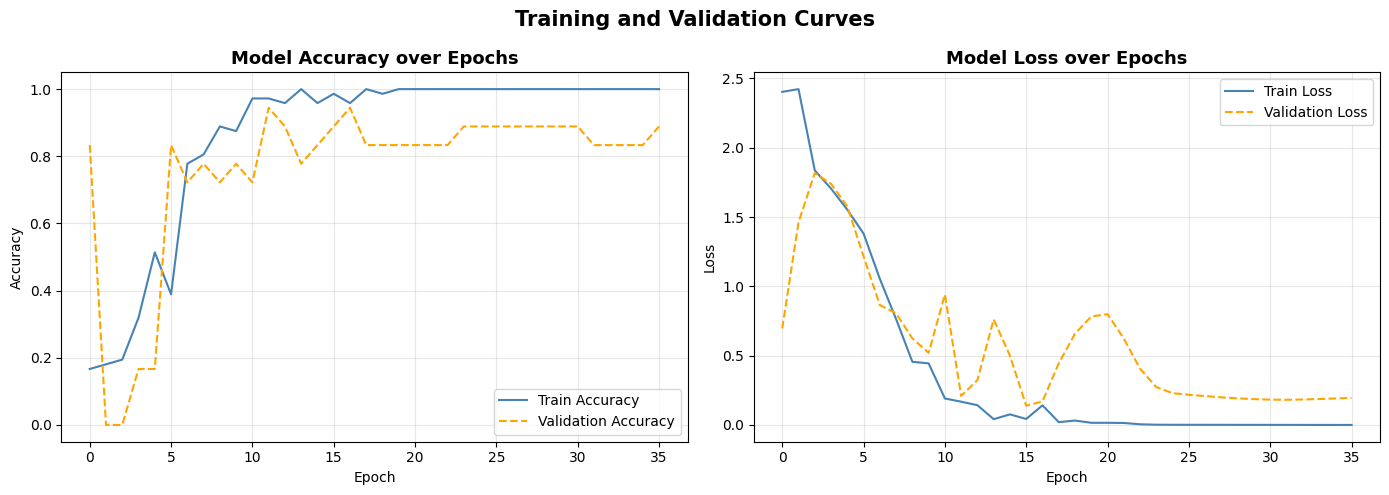

In [11]:
#  Plot Training Curves
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Accuracy
axes[0].plot(history.history['accuracy'],     label='Train Accuracy',      color='steelblue')
axes[0].plot(history.history['val_accuracy'], label='Validation Accuracy', color='orange',    linestyle='--')
axes[0].set_title('Model Accuracy over Epochs', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Loss
axes[1].plot(history.history['loss'],     label='Train Loss',      color='steelblue')
axes[1].plot(history.history['val_loss'], label='Validation Loss', color='orange', linestyle='--')
axes[1].set_title('Model Loss over Epochs', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.suptitle('Training and Validation Curves', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('task4_training_curves.png', dpi=150, bbox_inches='tight')
plt.show()

In [12]:
test_dir = '/content/extracted_dataset/FruitinAmazon/test'

# Create test dataset with normalization
test_ds = tf.keras.preprocessing.image_dataset_from_directory(
    test_dir,
    labels='inferred',
    label_mode='int',
    image_size=(img_height, img_width),
    interpolation='nearest',
    batch_size=batch_size,
    shuffle=False # Typically, testing data is not shuffled
)

# Apply normalization (assuming 'rescale' is defined from earlier cells)
test_ds = test_ds.map(lambda x, y: (rescale(x), y))

# Evaluate the model on the test dataset
test_loss, test_accuracy = model.evaluate(test_ds, verbose=1)


print(f"  Test Loss     : {test_loss:.4f}")
print(f"  Test Accuracy : {test_accuracy * 100:.2f}%")

Found 30 files belonging to 6 classes.
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 188ms/step - accuracy: 0.6333 - loss: 0.8955
  Test Loss     : 0.8955
  Test Accuracy : 63.33%


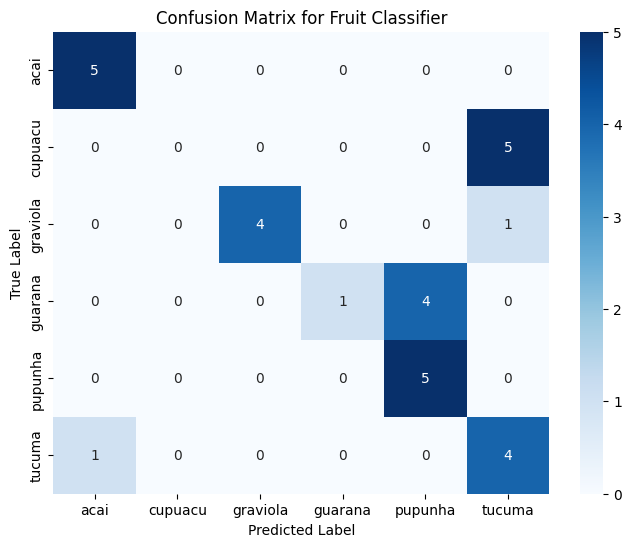

In [17]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

# Get class names from `class_dirs`
class_names = class_dirs

# Compute the confusion matrix
cm = confusion_matrix(y_true, y_pred)

# Plot the confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.title('Confusion Matrix for Fruit Classifier')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

In [13]:
#  Save
MODEL_SAVE_PATH = 'cnn_fruit_classifier.h5'
model.save(MODEL_SAVE_PATH)
print(f"✅ Model saved to '{MODEL_SAVE_PATH}'")

✅ Model saved to 'cnn_fruit_classifier.h5'


In [14]:
# ─── Load ────────────────────────────────────────────────────────────────
loaded_model = keras.models.load_model(MODEL_SAVE_PATH)
print(f"✅ Model loaded from '{MODEL_SAVE_PATH}'")

# Re-evaluate loaded model
print("\n📊 Re-evaluating loaded model on TEST set...")
loaded_loss, loaded_acc = loaded_model.evaluate(test_ds, verbose=1)

print(f"\n{'='*40}")
print(f"  Loaded Model Test Loss     : {loaded_loss:.4f}")
print(f"  Loaded Model Test Accuracy : {loaded_acc * 100:.2f}%")
print(f"{'='*40}")
print("\n✅ Loaded model matches original — save/load successful.")

✅ Model loaded from 'cnn_fruit_classifier.h5'

📊 Re-evaluating loaded model on TEST set...
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 483ms/step - accuracy: 0.6333 - loss: 0.8955

  Loaded Model Test Loss     : 0.8955
  Loaded Model Test Accuracy : 63.33%

✅ Loaded model matches original — save/load successful.


In [15]:
import numpy as np

# ─── Gather all true labels and predictions from test_ds ─────────────────
y_true = []
y_pred_probs = []

for images, labels in test_ds:
    probs = loaded_model.predict(images, verbose=0)
    y_pred_probs.extend(probs)
    y_true.extend(labels.numpy())

y_true      = np.array(y_true)
y_pred_probs = np.array(y_pred_probs)

# Convert probabilities → class indices
y_pred = np.argmax(y_pred_probs, axis=1)

print(f"Total test samples : {len(y_true)}")
print(f"Prediction sample  : {y_pred[:10]}")
print(f"True label sample  : {y_true[:10]}")

Total test samples : 30
Prediction sample  : [0 0 0 0 0 5 5 5 5 5]
True label sample  : [0 0 0 0 0 1 1 1 1 1]
